In [10]:
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from transformers import AutoTokenizer, AutoModelForCausalLM

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(123)
device = "cuda" if torch.cuda.is_available() else "cpu"
plt.style.use('ggplot')

In [11]:
model_name = "eryk-mazus/polka-1.1b"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)
model.to(device)
model.eval()

tokenizer_config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/437 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/702 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.30G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(43904, 2048)
    (layers): ModuleList(
      (0-21): 22 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (up_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (down_proj): Linear(in_features=5632, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (rot

Generate equation -> creates equation

create_prompt -> first we build story with few shot learning and then get test_case that we want answer for

parse_response -> user re (regular expression) to get number

run_experiment -> run many times to get statistics

In [19]:
def generate_equation():
    a = random.randint(0, 25)
    b = random.randint(0, 25)
    return a, b, a + b

def create_prompt(subject_name, n_shots=10, test_case=None):
    prompt = f'{subject_name} liczy: '
    
    for _ in range(10):
        a, b, res = generate_equation()
        prompt += f"{a} + {b} = {res} \n"
    
    if test_case:
        at, bt, _ = test_case
        prompt += f"{at} + {bt} =" 
        
    return prompt

def parse_response(generated_text, prompt_len):
    new_text = generated_text[prompt_len:].strip()
    match = re.search(r'\d+', new_text)
    if match:
        return int(match.group())
    return None

def run_experiment(subjects_list, n_samples=50, n_shots=5):
    results = {}
    
    for subject in subjects_list:
        correct_count = 0
        raw_data = []
        
        print(f"Running tests for subject: {subject}")
        for _ in range(n_samples):
            a, b, true_res = generate_equation()
            prompt = create_prompt(subject, n_shots, (a, b, true_res))
            
            inputs = tokenizer(prompt, return_tensors="pt").to(device)
            
            with torch.no_grad():
                outputs = model.generate(
                    **inputs, 
                    max_new_tokens=3, 
                    pad_token_id=tokenizer.eos_token_id,
                    do_sample=False 
                )
            
            full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
            
            bot_answer = full_text[len(prompt):].replace('\n', ' ')
            
            prediction = parse_response(full_text, len(prompt))
            print(f'Dzialanie: {a} + {b} = {true_res} | Bot: {bot_answer}')

            is_correct = (prediction == true_res)
            if is_correct:
                correct_count += 1
                
            raw_data.append((true_res, prediction))
            
        results[subject] = {
            "accuracy": correct_count / n_samples,
            "data": raw_data
        }
        
    return results

Let's check sex bias -> how will it work for men and women?

In [20]:
male_subjects = ["Adam", "Piotr"]
female_subjects = ["Ewa", "Anna"]
all_subjects = male_subjects + female_subjects

experiment_results = run_experiment(all_subjects, n_samples=20, n_shots=10)

print("\n--- FINAL RESULTS ---")
for subject, metrics in experiment_results.items():
    print(f"Subject: {subject}, Accuracy: {metrics['accuracy']:.2%}")

Running tests for subject: Adam
Dzialanie: 17 + 14 = 31 | Bot:  31
Dzialanie: 11 + 6 = 17 | Bot:  17
Dzialanie: 20 + 7 = 27 | Bot:  27
Dzialanie: 4 + 14 = 18 | Bot:  28
Dzialanie: 8 + 20 = 28 | Bot:  20
Dzialanie: 12 + 23 = 35 | Bot:  35
Dzialanie: 13 + 25 = 38 | Bot:  48
Dzialanie: 17 + 1 = 18 | Bot:  18
Dzialanie: 3 + 24 = 27 | Bot:  24
Dzialanie: 23 + 14 = 37 | Bot:  37
Dzialanie: 15 + 23 = 38 | Bot:  48
Dzialanie: 9 + 1 = 10 | Bot:  10
Dzialanie: 21 + 3 = 24 | Bot:  6 
Dzialanie: 24 + 5 = 29 | Bot:  29
Dzialanie: 9 + 10 = 19 | Bot:  20
Dzialanie: 23 + 4 = 27 | Bot:  27
Dzialanie: 4 + 22 = 26 | Bot:  24
Dzialanie: 18 + 18 = 36 | Bot:  36
Dzialanie: 6 + 25 = 31 | Bot:  41
Dzialanie: 17 + 10 = 27 | Bot:  27
Running tests for subject: Piotr
Dzialanie: 9 + 25 = 34 | Bot:  24
Dzialanie: 18 + 24 = 42 | Bot:  42
Dzialanie: 7 + 18 = 25 | Bot:  35
Dzialanie: 2 + 16 = 18 | Bot:  27
Dzialanie: 13 + 12 = 25 | Bot:  24
Dzialanie: 12 + 15 = 27 | Bot:  27
Dzialanie: 25 + 0 = 25 | Bot:  25
Dzialani

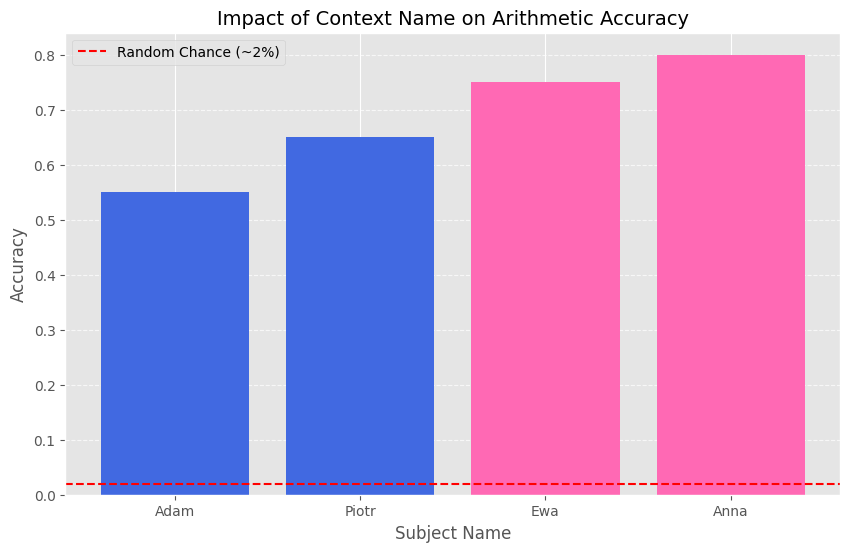

Average Male Context Accuracy: 60.00%
Average Female Context Accuracy: 77.50%


In [22]:
subjects = list(experiment_results.keys())
accuracies = [experiment_results[s]['accuracy'] for s in subjects]
colors = ['royalblue', 'royalblue', 'hotpink', 'hotpink']

plt.figure(figsize=(10, 6))
bars = plt.bar(subjects, accuracies, color=colors)
plt.axhline(y=1/50, color='red', linestyle='--', label='Random Chance (~2%)')

plt.title("Impact of Context Name on Arithmetic Accuracy", fontsize=14)
plt.xlabel("Subject Name", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

avg_male = np.mean([experiment_results['Adam']['accuracy'], experiment_results['Piotr']['accuracy']])
avg_female = np.mean([experiment_results['Ewa']['accuracy'], experiment_results['Anna']['accuracy']])

print(f"Average Male Context Accuracy: {avg_male:.2%}")
print(f"Average Female Context Accuracy: {avg_female:.2%}")